In [29]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')
# from plotly import express as px
# from scipy import signal as sn
# from scipy.constants import Rydberg as R
from scipy import optimize as o
plt.rcParams.update({
    "figure.figsize": (12, 9),
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 15})

In [30]:
LU_cubo = pd.read_csv('datos/times_LU_cubo.csv')
GS_cubo = pd.read_csv('datos/times_GS_cubo.csv')
pcg_cubo = pd.read_csv('datos/times_pcg_cubo.csv')

n_LU = LU_cubo['N']
t_LU = LU_cubo['t']
n_GS = GS_cubo['N']
t_GS = GS_cubo['t']
n_pcg = pcg_cubo['N']
t_pcg = pcg_cubo['t']

k_GS = GS_cubo['k']
k_pcg = pcg_cubo['iter']


x_LU = LU_cubo['norm_x']
n_len = len(x_LU)

x_GS = GS_cubo['norm_x'][:n_len]
x_pcg = pcg_cubo['norm_x'][:n_len]




In [31]:
print(np.linalg.norm(x_LU-x_pcg))
print(np.linalg.norm(x_pcg-x_GS))
print(np.sum((n_pcg-n_GS[:n_len])**2))
print(np.sum((n_LU-n_pcg[:n_len])**2))



1.3452151410634088e-15
3.2435387122154287e-07
0.0
0


In [32]:
cut = 1
postcut = -3

p_LU = np.polyfit(np.log(n_LU[cut:postcut]),np.log(t_LU[cut:postcut]),1); print(p_LU, 'LU')
p_GS = np.polyfit(np.log(n_GS[cut:-8]),np.log(t_GS[cut:-8]),1); print(p_GS, 'GS')
p_pcg = np.polyfit(np.log(n_pcg[-8:]),np.log(t_pcg[-8:]),1); print(p_pcg, 'pcg')

z_LU = np.poly1d(p_LU)
z_GS = np.poly1d(p_GS)
z_pcg = np.poly1d(p_pcg)



[  2.29486161 -11.32386088] LU
[ 1.59119126 -8.62618402] GS
[  1.34352455 -16.20992765] pcg


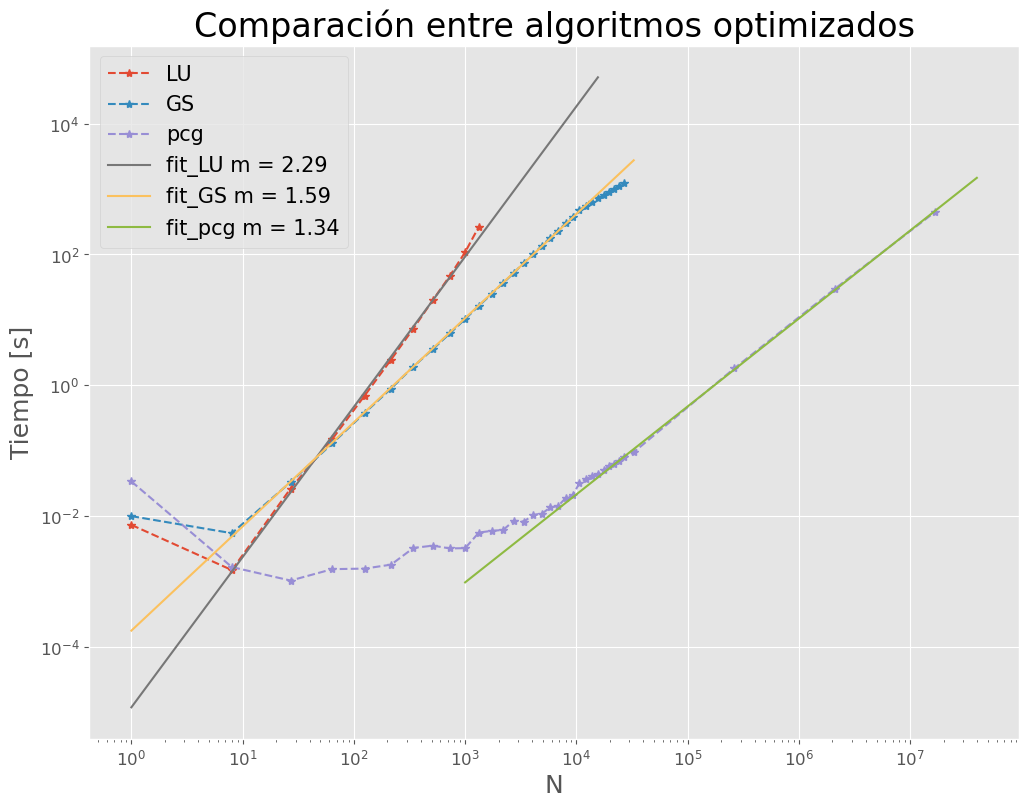

In [33]:
k = np.logspace(3,7.6,50,base=10)
plt.loglog(n_LU[:-2],t_LU[:-2],'--*',label='LU')

plt.loglog(n_GS,t_GS,'--*',label='GS')

plt.loglog(n_pcg,t_pcg,'--*',label='pcg')
plt.plot(n_pcg[:-9],np.exp(z_LU(np.log(n_pcg[:-9]))),label=f'fit_LU m = {p_LU[0]:.2f}')
plt.plot(n_pcg[:-3],np.exp(z_GS(np.log(n_pcg[:-3]))),label=f'fit_GS m = {p_GS[0]:.2f}')
plt.plot(k,np.exp(z_pcg(np.log(k))),label=f'fit_pcg m = {p_pcg[0]:.2f}')

plt.title('Comparación entre algoritmos optimizados')
plt.xlabel('N')
plt.ylabel('Tiempo [s]')
plt.legend()

plt.savefig(
    "graficos/LU-GS-PCG.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
    dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
    bbox_inches="tight",  # recorta bordes en blanco innecesarios
    pad_inches=0.05,   # un poquito de espacio alrededor
    transparent=False, # True si querés fondo transparente
    facecolor="white"  # color de fondo (se aplica si transparent=False)
)


In [34]:
cut = 2
post_cut = -8
pk_GS = np.polyfit(np.log(n_GS[cut:post_cut]),np.log(k_GS[cut:post_cut]),1); print(pk_GS, 'GS')
pk_pcg = np.polyfit(np.log(n_pcg[-15:-4]),np.log(k_pcg[-15:-4]),1); print(pk_pcg, 'pcg')

zk_GS = np.poly1d(pk_GS)
zk_pcg = np.poly1d(pk_pcg)

[0.59270543 1.3460544 ] GS
[0.33799991 0.85867137] pcg


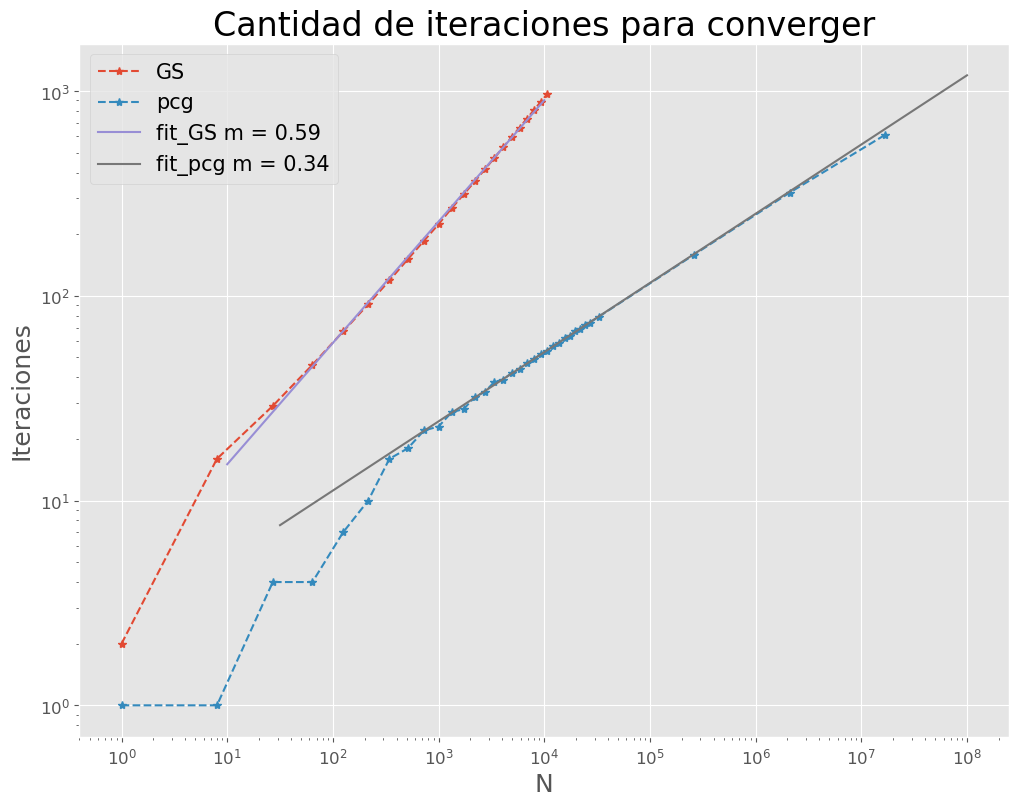

In [35]:
k = np.logspace(1,4,50,base=10)
k2 = np.logspace(1.5,8,50,base=10)

# plt.loglog(n_LU,t_LU,'--*',label='LU')
plt.loglog(n_GS[:post_cut],k_GS[:post_cut],'--*',label='GS')
plt.loglog(n_pcg,k_pcg,'--*',label='pcg')



# plt.plot(n_pcg[:-9],np.exp(z_LU(np.log(n_pcg[:-9]))),label=f'fit_LU m = {p_LU[0]:.2f}')
# plt.plot(n_pcg[:-9],np.exp(z_GS(np.log(n_pcg[:-9]))),label=f'fit_GS m = {p_GS[0]:.2f}')
plt.plot(k,np.exp(zk_GS(np.log(k))),label=f'fit_GS m = {pk_GS[0]:.2f}')
plt.plot(k2,np.exp(zk_pcg(np.log(k2))),label=f'fit_pcg m = {pk_pcg[0]:.2f}')



plt.title('Cantidad de iteraciones para converger')
plt.xlabel('N')
plt.ylabel('Iteraciones')
plt.legend()

plt.savefig(
    "graficos/GS-PCG-k.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
    dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
    bbox_inches="tight",  # recorta bordes en blanco innecesarios
    pad_inches=0.05,   # un poquito de espacio alrededor
    transparent=False, # True si querés fondo transparente
    facecolor="white"  # color de fondo (se aplica si transparent=False)
)
